In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y')

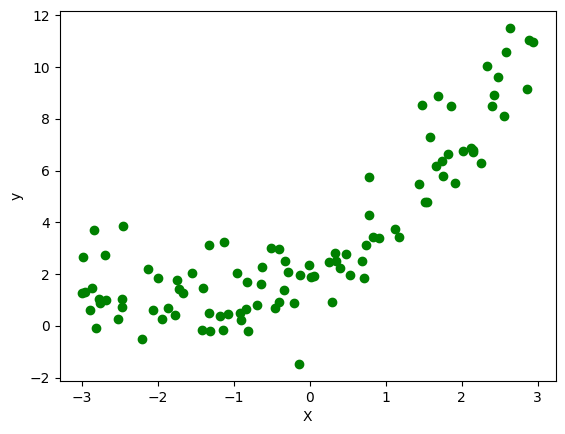

In [2]:
X = 6 * np.random.rand(100, 1) - 3 
y = 0.5*X**2 + 1.5*X + 2 + np.random.randn(100, 1) # quadratic y = 0.5x^2 + 1.5x + 2 + outliers

plt.scatter(X, y, color = 'g')
plt.xlabel('X')
plt.ylabel('y')

In [3]:
# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

<Axes: >

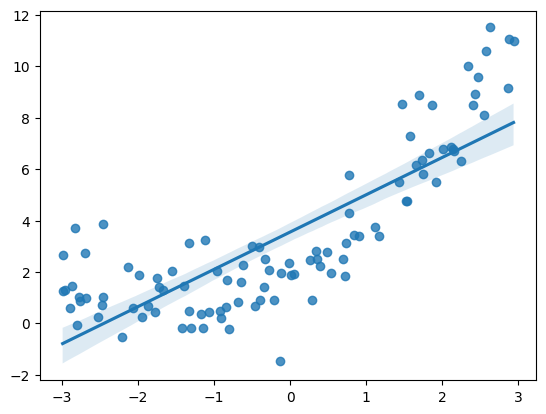

In [4]:
import seaborn as sns

sns.regplot(x= X,  y=y)


In [5]:
## Apply Simple LR
from sklearn.linear_model import LinearRegression

In [6]:
regression_1 = LinearRegression(n_jobs=-1) # njobs run on how many processors are there

In [7]:
regression_1.fit(X_train, y_train)   

LinearRegression(n_jobs=-1)

In [8]:
y_pred_1 = regression_1.predict(X_test)

In [11]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_1)
print(score)

0.5735936873829445


Text(0, 0.5, 'y')

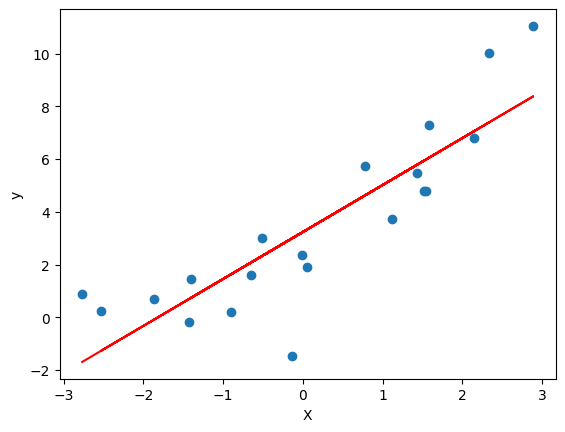

In [12]:
plt.plot(X_train, regression_1.predict(X_train), color = 'r')
plt.scatter(X_train, y_train)
plt.xlabel("X")
plt.ylabel("y")

# Apply Polynomial Transformation

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
poly = PolynomialFeatures(degree=2, include_bias=True)

In [29]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [30]:
X_train_poly

array([[ 1.00000000e+00, -2.76574192e+00,  7.64932834e+00],
       [ 1.00000000e+00,  7.74794427e-01,  6.00306405e-01],
       [ 1.00000000e+00,  2.88509360e+00,  8.32376505e+00],
       [ 1.00000000e+00, -1.42232033e+00,  2.02299512e+00],
       [ 1.00000000e+00,  1.52167683e+00,  2.31550038e+00],
       [ 1.00000000e+00,  1.54289347e+00,  2.38052026e+00],
       [ 1.00000000e+00, -9.05585520e-01,  8.20085134e-01],
       [ 1.00000000e+00,  1.12170352e+00,  1.25821879e+00],
       [ 1.00000000e+00,  1.58020098e+00,  2.49703513e+00],
       [ 1.00000000e+00,  2.14505444e+00,  4.60125854e+00],
       [ 1.00000000e+00, -6.46895680e-01,  4.18474021e-01],
       [ 1.00000000e+00, -1.56187803e-02,  2.43946297e-04],
       [ 1.00000000e+00, -1.39881072e+00,  1.95667143e+00],
       [ 1.00000000e+00,  1.43352568e+00,  2.05499587e+00],
       [ 1.00000000e+00, -2.52642878e+00,  6.38284240e+00],
       [ 1.00000000e+00, -1.36501729e-01,  1.86327221e-02],
       [ 1.00000000e+00,  5.57093665e-02

In [31]:
X_test_poly

array([[ 1.00000000e+00, -1.14610130e+00,  1.31354819e+00],
       [ 1.00000000e+00, -2.45793866e+00,  6.04146245e+00],
       [ 1.00000000e+00, -3.41042334e-01,  1.16309874e-01],
       [ 1.00000000e+00, -2.46367753e+00,  6.06970696e+00],
       [ 1.00000000e+00, -2.89636839e+00,  8.38894985e+00],
       [ 1.00000000e+00, -2.68188365e+00,  7.19249989e+00],
       [ 1.00000000e+00, -4.59137845e-01,  2.10807561e-01],
       [ 1.00000000e+00,  1.91304794e+00,  3.65975241e+00],
       [ 1.00000000e+00,  2.57689441e+00,  6.64038481e+00],
       [ 1.00000000e+00,  2.14986570e+00,  4.62192253e+00],
       [ 1.00000000e+00, -9.60687929e-01,  9.22921297e-01],
       [ 1.00000000e+00, -2.06153236e+00,  4.24991565e+00],
       [ 1.00000000e+00, -2.12861070e+00,  4.53098353e+00],
       [ 1.00000000e+00, -1.77598421e+00,  3.15411990e+00],
       [ 1.00000000e+00,  2.63357182e+00,  6.93570051e+00],
       [ 1.00000000e+00, -1.55472970e+00,  2.41718445e+00],
       [ 1.00000000e+00,  1.74044586e+00

In [ ]:
from sklearn.linear_model import LinearRegression

regression_p = LinearRegression(n_jobs=-1) # njobs run on how many processors are there
regression_p.fit(X_train_poly, y_train)
y_pred_p = regression_p.predict(X_test_poly)

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_p)
print(score)

0.8500318139992293


In [34]:
regression_p.coef_

array([[0.        , 1.74786879, 0.48850583]])

### Best fit line (blue one):

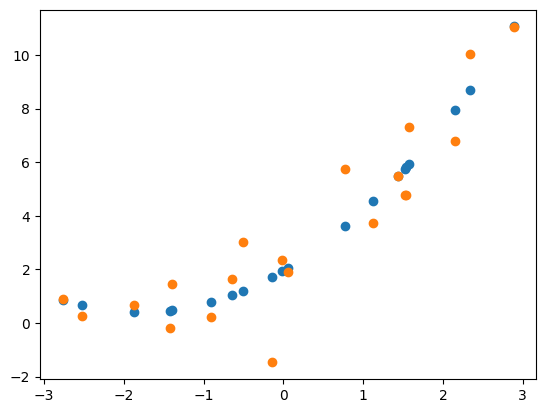

In [38]:
plt.scatter(X_train, regression_p.predict(X_train_poly)) # blue one is best fit line
plt.scatter(X_train, y_train)

## What if we increase the degree to 3

In [44]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_train_poly

array([[ 1.00000000e+00, -2.76574192e+00,  7.64932834e+00,
        -2.11560680e+01],
       [ 1.00000000e+00,  7.74794427e-01,  6.00306405e-01,
         4.65114057e-01],
       [ 1.00000000e+00,  2.88509360e+00,  8.32376505e+00,
         2.40148412e+01],
       [ 1.00000000e+00, -1.42232033e+00,  2.02299512e+00,
        -2.87734709e+00],
       [ 1.00000000e+00,  1.52167683e+00,  2.31550038e+00,
         3.52344328e+00],
       [ 1.00000000e+00,  1.54289347e+00,  2.38052026e+00,
         3.67288917e+00],
       [ 1.00000000e+00, -9.05585520e-01,  8.20085134e-01,
        -7.42657223e-01],
       [ 1.00000000e+00,  1.12170352e+00,  1.25821879e+00,
         1.41134845e+00],
       [ 1.00000000e+00,  1.58020098e+00,  2.49703513e+00,
         3.94581736e+00],
       [ 1.00000000e+00,  2.14505444e+00,  4.60125854e+00,
         9.86995006e+00],
       [ 1.00000000e+00, -6.46895680e-01,  4.18474021e-01,
        -2.70709036e-01],
       [ 1.00000000e+00, -1.56187803e-02,  2.43946297e-04,
      

In [45]:
from sklearn.linear_model import LinearRegression

regression_p3 = LinearRegression(n_jobs=-1) # njobs run on how many processors are there
regression_p3.fit(X_train_poly, y_train)   
y_pred_p = regression_p3.predict(X_test_poly)

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_p)
print(score)

0.8479808124400928


In [49]:
# Prediction of new dataset
X_new = np.linspace(-3, 3, 200).reshape(200, 1)  # create a new dataset
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

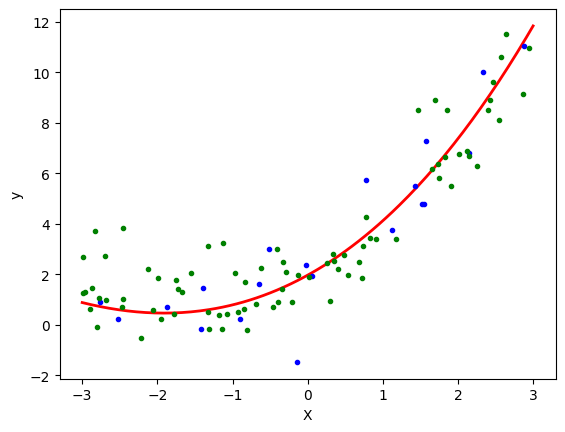

In [ ]:
y_new = regression_p3.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth = 2, label= "New Predictions")
plt.plot(X_train, y_train, "b.", label = "Training points")
plt.plot(X_test, y_test, "g.", label = "Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Pipelining:

In [52]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
  X_new = np.linspace(-3, 3, 200).reshape(200, 1)  # create a new dataset
  poly_features = PolynomialFeatures(degree=degree, include_bias=True)
  lin_reg = LinearRegression()
  
  # Create the pipeline
  poly_reg = Pipeline([
    ("poly_features", poly_features),
    ("lin_reg", lin_reg)
  ])

  poly_reg.fit(X_train, y_train)
  y_pred_new = poly_reg.predict(X_new)

  plt.plot(X_new, y_pred_new, 'r', label= "Degree" + str(degree), linewidth=2)
  plt.plot(X_new, y_new, "r-", linewidth = 2, label= "New Predictions")
  plt.plot(X_train, y_train, "b.", label = "Training points")
  plt.plot(X_test, y_test, "g.", label = "Testing points")
  plt.xlabel("X")
  plt.ylabel("y")
  plt.show()
  



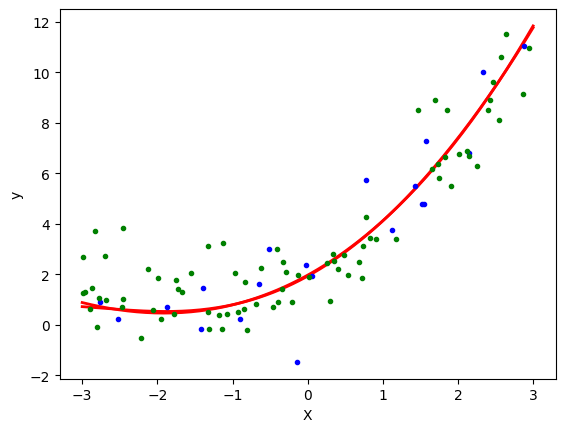

In [61]:
poly_regression(5)

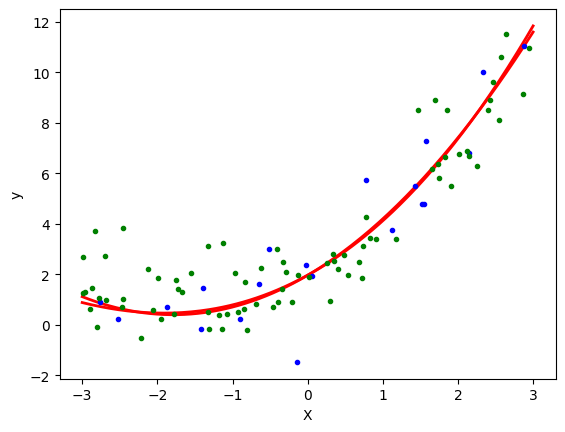

In [62]:
poly_regression(2)

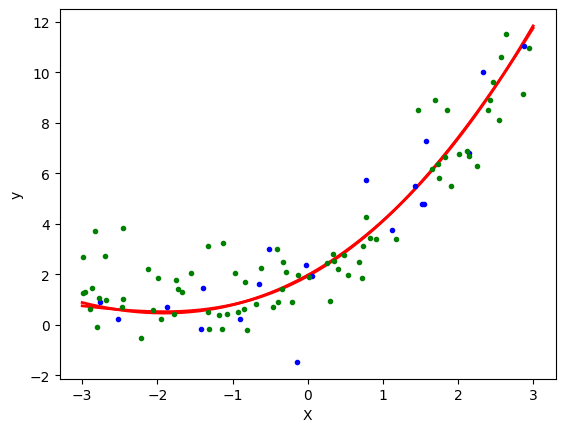

In [63]:
poly_regression(4)

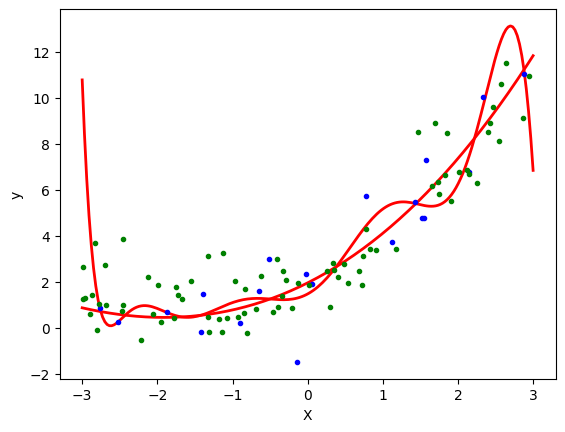

In [64]:
poly_regression(10)